# The Retrospective

---

## The brief

> **Client:** Rolling Beats Magazine (music publication)
>
> **Your role:** Data Journalist
>
> **Context:** Rolling Beats is preparing their "25 Years of Pop" retrospective issue. The editorial team wants data-driven stories that reveal how popular music has evolved since 2000. They're looking for surprising trends, cultural shifts, and compelling visualizations that tell the story of modern pop.
>
> You have access to 25 years of Billboard Hot 100 chart data (2000-2024), combined with Spotify's audio analysis of each track.
>
> **Your task:** Explore 25 years of chart data and uncover the stories hidden within. What trends emerge? What has changed, and what has stayed the same? Find insights that would make readers say "I never knew that."

---

## Understanding the data

This dataset spans an incredible period in music history:

- **2000**: The Napster era. CD sales at their peak.
- **2003-2010**: The iTunes revolution. Digital singles take over.
- **2010-2015**: YouTube becomes a music platform. Viral hits emerge.
- **2015-present**: Streaming dominance. Billboard changes its methodology to include streams.

### What the Billboard Hot 100 measures

The Hot 100 combines:
- **Radio airplay** (still matters!)
- **Streaming** (Spotify, Apple Music, YouTube, etc.)
- **Sales** (downloads, physical)

The formula has changed over time, which creates interesting dynamics – a streaming-era hit might look different from a radio-era hit.

## A note on data quality

- **Release dates vary**: Older songs have less precise dates (just year). Newer songs have full dates.
- **Catalog songs re-chart**: Old songs can re-enter the chart years later (TikTok effect, movie placements)
- **Christmas songs**: They return every year! December data is always unusual.
- **Methodology changes**: Billboard changed how it counts streams in 2013, 2018, and 2020.

**Tip for journalists:** Be careful about claiming trends – make sure the pattern isn't just an artifact of methodology changes!

---

## Suggested starting points

Think like a journalist. What stories would surprise readers?

- How has the **"sound" of popular music changed**? Track audio features across the decades.
- Has music gotten **more or less explicit** over time? More or less acoustic?
- Which artists **dominated each era**? Who had the longest chart presence?
- Are there **seasonal patterns** in the charts? (Christmas songs, summer anthems?)
- How long do **#1 hits** typically stay at the top? Has this changed?
- What's the average **"age" of a hit song**? Do old songs still chart? (Hint: compare release dates to chart dates)
- Have songs gotten **shorter or longer**? What about tempo – faster or slower?

**THESE ARE NOT QUESTIONS THAT I EXPECT YOU TO ANSWER, JUST IDEAS TO GET YOU STARTED.**

---

## Loading the data

In [1]:
pip install google-cloud-bigquery google-auth

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install google-cloud-bigquery-storage

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install db-dtypes

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colormaps

In [3]:
from google.cloud.bigquery import Client
from google.auth import load_credentials_from_file

In [4]:
credentials, project = load_credentials_from_file("bigquery-access-key.json")

In [5]:

client = Client(
    project=project, credentials=credentials
)

In [6]:
# List of all datasets
datasets = [
    "tracks",
    "artists",
    "audio_features",
    "chart_positions",
    "tracks_artists_mapping"
]

# making a function for ease
def load(dataset_name):
    
    # Selecting one of them and constructing a query
    # to the database
    dataset = dataset_name
    
    query = f"""
    SELECT *
    FROM `hyper-python-2025.assessment.{dataset}`
    """
    
    # Running the query and storing the results as a df
    job = client.query(query)
    df = job.to_dataframe()
    return df

# running a loop using the function to load all dataframes faster
for dataset in datasets:
    if dataset == 'tracks':
        tracks = load(dataset)
    elif dataset == 'artists':
        artists = load(dataset)
    elif dataset == 'audio_features':
        audio = load(dataset)
    elif dataset == 'chart_positions':
        charts = load(dataset)
    else:
        mapping = load(dataset)

## Inspecting the data

In [7]:
tracks.head(10)

,track_id,name,duration_ms,release_date,album_type,explicit
0,6zeDYmP3ARpURvpK29Q09P,Someday,242800,1900-01-01,album,False
1,4T7fVN4ZOFE3JoGyaxZL6O,Falls Apart,255160,1900-01-01,album,False
2,5CMVGP24paZIukljDj0iWc,Jingle Bells (with The Ken Lane Singers),156666,1945,compilation,False
3,04vLj9QUXoKdRlsp3gkURo,Mele Kalikimaka (Merry Christmas),175333,1945-01-01,compilation,False
4,25leEEaz1gIpp7o21Fqyjo,Here Comes Santa Claus (Right Down Santa Claus...,150266,1947,album,False
5,1dtIaSlyrLI04sqYa8nLyN,Rudolph the Red-Nosed Reindeer,186733,1947,album,False
6,4HEOgBHRCExyYVeTyrXsnL,Jingle Bells - Remastered 1999,120693,1957-09,album,False
7,4HEOgBHRCExyYVeTyrXsnL,Jingle Bells - Remastered 1999,120693,1957-09,album,False
8,3QiAAp20rPC3dcAtKtMaqQ,Blue Christmas,129173,1957-10-15,album,False
9,7vQbuQcyTflfCIOu3Uzzya,Jingle Bell Rock,130973,1957-12-02,single,False


In [8]:
artists.head(10)

,artist_id,name,popularity,followers
0,13UwRaADQI0yTqjPBDkk6d,J-Shin (Featuring LaTocha Scott of Xscape),0,253
1,2LmsYeN3MzzZ9zhuZhNyqO,A*Teens,0,10
2,5Q25oFANw7zA3kD2DPaJ8D,The 2000s Karaoke Band,0,26
3,7u7ORV6MVjId1jfJwMdakL,2000s Karaoke Band,0,27
4,0LyfQWJT6nXafLPZqxe9Of,Various Artists,0,2542450
5,0sghswo09Y90G2q0eha4SW,Joe Osborne,0,23
6,14qvHyl1HApvsMrtxXljMM,Archuleta Maroon,0,21
7,1b9wvEcR1vuxoVu6isElSd,Anand Clique,0,109
8,5lfsewMdyn5f9okNcLUtYM,Xander Phillips,0,79
9,0o9FGMZT1bOTSGYFb7BoWz,Drop That Thun Thun,0,250


In [9]:
audio.head(10)

,track_id,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,3lZpvPprN56RWqDqrKy9vl,0.0000,0.5320,3.0,-7.447,1.0,0.0000,0.976,0.000,0.0000,0.0000,0.000,0.0
8,0u1Sp4e3Phbbg9U215CMBe,0.0746,0.0420,2.0,-25.752,1.0,0.0408,0.925,0.615,0.0484,0.0347,77.810,4.0
9,4ecrWAB11dwNLB46lqeRHF,0.0772,0.0124,0.0,-33.833,1.0,0.0435,0.951,0.749,0.0748,0.0446,81.059,4.0


In [10]:
charts.head(10)

,chart_week,list_position,track_id
0,2021-07-10,42,000TJlEJQ3nafsm1hBWpoj
1,2003-07-19,60,003FTlCpBTM4eSqYSWPv4H
2,2003-07-26,60,003FTlCpBTM4eSqYSWPv4H
3,2003-08-02,64,003FTlCpBTM4eSqYSWPv4H
4,2003-07-12,66,003FTlCpBTM4eSqYSWPv4H
5,2003-08-09,66,003FTlCpBTM4eSqYSWPv4H
6,2003-06-28,67,003FTlCpBTM4eSqYSWPv4H
7,2003-07-05,67,003FTlCpBTM4eSqYSWPv4H
8,2003-06-21,71,003FTlCpBTM4eSqYSWPv4H
9,2003-08-16,85,003FTlCpBTM4eSqYSWPv4H


In [11]:
mapping.head(10)

,track_id,artist_id
0,00FQb4jTyendYWaN8pK0wa,4zmKGsrXjLmljb5fTaBTot
1,00FQb4jTyendYWaN8pK0wa,6GGtHZgBycCgGBUhZo81xe
2,00FQb4jTyendYWaN8pK0wa,22DH8NChecsgPxDjA4pqer
3,00FQb4jTyendYWaN8pK0wa,7JVNRVPeXFAOdMrxOHNjVv
4,00FQb4jTyendYWaN8pK0wa,24jvD83UgLmrdGjhWTFslY
5,00FQb4jTyendYWaN8pK0wa,2nMeu6UenVvwUktBCpLMK9
6,00FQb4jTyendYWaN8pK0wa,6PUIzlqotEmPuBfjbwYWOB
7,00FQb4jTyendYWaN8pK0wa,5Y6nVaayzitvsD5F7nr3DV
8,00FQb4jTyendYWaN8pK0wa,4VSg5K1hnbmIg4PwRdY6wV
9,00FQb4jTyendYWaN8pK0wa,1y3r6RXiJZNBV1EI0NggpS


## Cleaning the Data

### Tracks

In [12]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11070 entries, 0 to 11069
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   track_id      11070 non-null  object 
 1   name          11070 non-null  object 
 2   duration_ms   11070 non-null  Int64  
 3   release_date  11070 non-null  object 
 4   album_type    11070 non-null  object 
 5   explicit      11070 non-null  boolean
dtypes: Int64(1), boolean(1), object(4)
memory usage: 465.0+ KB


In [13]:
tracks.describe(include='O')

,track_id,name,release_date,album_type
count,11070,11070,11070,11070
unique,10783,10151,2440,3
top,7uKcScNXuO3MWw6LowBjW1,You,2013-01-01,album
freq,9,10,153,8977


In [14]:
tracks.describe()

,duration_ms
count,11070.0
mean,218972.503433
std,49259.141037
min,7500.0
25%,189269.5
50%,215722.0
75%,243773.0
max,1037906.0


In [15]:
tracks.shape

(11070, 6)

#### Notes:

- No **Null** values
- Release date is stored as object -> need to change to date
- Release date has inconsistencies (some only have year, some have full date) -> decide what to change and change
     - Also it has false dates - like 1900 etc.
    - Inspect that column more
- Track_id column might have duplicates -> check for that, it should be every row and a unique track id

In [16]:
# making a copy so i dont work on the original
tracks_clean = tracks.copy()

In [17]:
# filtering for only these rows that have a yyyy format for release_date
year_only_mask = tracks_clean["release_date"].str.fullmatch(r"\d{4}")
tracks_clean[year_only_mask]

,track_id,name,duration_ms,release_date,album_type,explicit
2,5CMVGP24paZIukljDj0iWc,Jingle Bells (with The Ken Lane Singers),156666,1945,compilation,False
4,25leEEaz1gIpp7o21Fqyjo,Here Comes Santa Claus (Right Down Santa Claus...,150266,1947,album,False
5,1dtIaSlyrLI04sqYa8nLyN,Rudolph the Red-Nosed Reindeer,186733,1947,album,False
14,4PS1e8f2LvuTFgUs1Cn3ON,The Christmas Song (Merry Christmas To You),192160,1962,album,False
15,4PS1e8f2LvuTFgUs1Cn3ON,The Christmas Song (Merry Christmas To You),192160,1962,album,False
...,...,...,...,...,...,...
8543,4jCodMLVA5tV5MhPrspTfV,BEBE (feat. Anuel AA),217822,2018,album,True
8544,52OczisW5YSWIAJiygxs1M,STOOPID (feat. Bobby Shmurda),152000,2018,album,True
8545,2gGyUF86bijvQyjcOcJxNw,KIKA (feat. Tory Lanez),136031,2018,album,True
8546,0uEkcxPKj9JE0nxlwJWYlE,TIC TOC (feat. Lil Baby),135739,2018,album,True


In [18]:
# adding the full date to these rows

tracks_clean.loc[year_only_mask, 'release_date'] = tracks_clean.loc[year_only_mask, 'release_date'] + "-01-01"
tracks_clean[year_only_mask]

,track_id,name,duration_ms,release_date,album_type,explicit
2,5CMVGP24paZIukljDj0iWc,Jingle Bells (with The Ken Lane Singers),156666,1945-01-01,compilation,False
4,25leEEaz1gIpp7o21Fqyjo,Here Comes Santa Claus (Right Down Santa Claus...,150266,1947-01-01,album,False
5,1dtIaSlyrLI04sqYa8nLyN,Rudolph the Red-Nosed Reindeer,186733,1947-01-01,album,False
14,4PS1e8f2LvuTFgUs1Cn3ON,The Christmas Song (Merry Christmas To You),192160,1962-01-01,album,False
15,4PS1e8f2LvuTFgUs1Cn3ON,The Christmas Song (Merry Christmas To You),192160,1962-01-01,album,False
...,...,...,...,...,...,...
8543,4jCodMLVA5tV5MhPrspTfV,BEBE (feat. Anuel AA),217822,2018-01-01,album,True
8544,52OczisW5YSWIAJiygxs1M,STOOPID (feat. Bobby Shmurda),152000,2018-01-01,album,True
8545,2gGyUF86bijvQyjcOcJxNw,KIKA (feat. Tory Lanez),136031,2018-01-01,album,True
8546,0uEkcxPKj9JE0nxlwJWYlE,TIC TOC (feat. Lil Baby),135739,2018-01-01,album,True


In [19]:
# now filtering for the ones with the format yyyy-mm only
year_month_mask = tracks_clean["release_date"].str.fullmatch(r"\d{4}-\d{2}")
tracks_clean[year_month_mask]

,track_id,name,duration_ms,release_date,album_type,explicit
6,4HEOgBHRCExyYVeTyrXsnL,Jingle Bells - Remastered 1999,120693,1957-09,album,False
7,4HEOgBHRCExyYVeTyrXsnL,Jingle Bells - Remastered 1999,120693,1957-09,album,False


In [20]:
# adding the full date to these rows
tracks_clean.loc[year_month_mask, 'release_date'] = tracks_clean.loc[year_month_mask, 'release_date'] + "-01"
tracks_clean[year_month_mask]

,track_id,name,duration_ms,release_date,album_type,explicit
6,4HEOgBHRCExyYVeTyrXsnL,Jingle Bells - Remastered 1999,120693,1957-09-01,album,False
7,4HEOgBHRCExyYVeTyrXsnL,Jingle Bells - Remastered 1999,120693,1957-09-01,album,False


In [21]:
# now turning the objects into dates
tracks_clean['release_date'] = pd.to_datetime(tracks_clean['release_date'], yearfirst=True)
tracks_clean

,track_id,name,duration_ms,release_date,album_type,explicit
0,6zeDYmP3ARpURvpK29Q09P,Someday,242800,1900-01-01,album,False
1,4T7fVN4ZOFE3JoGyaxZL6O,Falls Apart,255160,1900-01-01,album,False
2,5CMVGP24paZIukljDj0iWc,Jingle Bells (with The Ken Lane Singers),156666,1945-01-01,compilation,False
3,04vLj9QUXoKdRlsp3gkURo,Mele Kalikimaka (Merry Christmas),175333,1945-01-01,compilation,False
4,25leEEaz1gIpp7o21Fqyjo,Here Comes Santa Claus (Right Down Santa Claus...,150266,1947-01-01,album,False
...,...,...,...,...,...,...
11065,5sRczgK1xkskY6HICpEKHa,"yes, and? - live version",199448,2024-10-01,album,True
11066,21SiVKUZKwWmL5C64G3R3e,don't wanna break up again,174006,2024-10-01,album,True
11067,4nQLt9m4p0fLUMOogvV6ZN,imperfect for you - live version,186201,2024-10-01,album,True
11068,4M7DbskLseolYL7rooP1SN,My Story,227813,2024-10-04,album,True


In [22]:
# fixing the dates that are impossible
tracks_clean[tracks_clean['release_date'] < "1945-01-01"]

,track_id,name,duration_ms,release_date,album_type,explicit
0,6zeDYmP3ARpURvpK29Q09P,Someday,242800,1900-01-01,album,False
1,4T7fVN4ZOFE3JoGyaxZL6O,Falls Apart,255160,1900-01-01,album,False


In [23]:
# assigning null values to these dates 
tracks_clean['release_date'] = tracks_clean['release_date'].replace("1900-01-01", np.nan)
tracks_clean

,track_id,name,duration_ms,release_date,album_type,explicit
0,6zeDYmP3ARpURvpK29Q09P,Someday,242800,NaT,album,False
1,4T7fVN4ZOFE3JoGyaxZL6O,Falls Apart,255160,NaT,album,False
2,5CMVGP24paZIukljDj0iWc,Jingle Bells (with The Ken Lane Singers),156666,1945-01-01,compilation,False
3,04vLj9QUXoKdRlsp3gkURo,Mele Kalikimaka (Merry Christmas),175333,1945-01-01,compilation,False
4,25leEEaz1gIpp7o21Fqyjo,Here Comes Santa Claus (Right Down Santa Claus...,150266,1947-01-01,album,False
...,...,...,...,...,...,...
11065,5sRczgK1xkskY6HICpEKHa,"yes, and? - live version",199448,2024-10-01,album,True
11066,21SiVKUZKwWmL5C64G3R3e,don't wanna break up again,174006,2024-10-01,album,True
11067,4nQLt9m4p0fLUMOogvV6ZN,imperfect for you - live version,186201,2024-10-01,album,True
11068,4M7DbskLseolYL7rooP1SN,My Story,227813,2024-10-04,album,True


In [24]:
# Checking now how many missing values exist
missing_tracks = round(tracks_clean['release_date'].isna().mean() * 100, 2)
print(f"The percentage of missing values in the 'release_date' column is {missing_tracks}%")

The percentage of missing values in the 'release_date' column is 0.02%


#### Since the missing values are now less than 0.02% of the whole dataset, I'm going to discard them as the percentage of the data is too small to affect the overall data quality.

In [25]:
tracks_clean = tracks_clean.dropna(subset=['release_date'])
tracks_clean

,track_id,name,duration_ms,release_date,album_type,explicit
2,5CMVGP24paZIukljDj0iWc,Jingle Bells (with The Ken Lane Singers),156666,1945-01-01,compilation,False
3,04vLj9QUXoKdRlsp3gkURo,Mele Kalikimaka (Merry Christmas),175333,1945-01-01,compilation,False
4,25leEEaz1gIpp7o21Fqyjo,Here Comes Santa Claus (Right Down Santa Claus...,150266,1947-01-01,album,False
5,1dtIaSlyrLI04sqYa8nLyN,Rudolph the Red-Nosed Reindeer,186733,1947-01-01,album,False
6,4HEOgBHRCExyYVeTyrXsnL,Jingle Bells - Remastered 1999,120693,1957-09-01,album,False
...,...,...,...,...,...,...
11065,5sRczgK1xkskY6HICpEKHa,"yes, and? - live version",199448,2024-10-01,album,True
11066,21SiVKUZKwWmL5C64G3R3e,don't wanna break up again,174006,2024-10-01,album,True
11067,4nQLt9m4p0fLUMOogvV6ZN,imperfect for you - live version,186201,2024-10-01,album,True
11068,4M7DbskLseolYL7rooP1SN,My Story,227813,2024-10-04,album,True


In [26]:
# checking for duplicates in track_id
tracks_clean[tracks_clean['track_id'].duplicated()]

,track_id,name,duration_ms,release_date,album_type,explicit
7,4HEOgBHRCExyYVeTyrXsnL,Jingle Bells - Remastered 1999,120693,1957-09-01,album,False
11,2uFaJJtFpPDc5Pa95XzTvg,Let It Snow! Let It Snow! Let It Snow!,117146,1959-01-01,album,False
15,4PS1e8f2LvuTFgUs1Cn3ON,The Christmas Song (Merry Christmas To You),192160,1962-01-01,album,False
16,4PS1e8f2LvuTFgUs1Cn3ON,The Christmas Song (Merry Christmas To You),192160,1962-01-01,album,False
34,7GVUmCP00eSsqc4tzj1sDD,Come and Get Your Love - Single Version,205933,1973-11-01,single,False
...,...,...,...,...,...,...
11002,0QpiyJbgWUjyAQNqjIA5tO,Hate Me,161142,2024-07-26,single,True
11024,1qIwin7JMVuX70qN6wD8ww,It's Up (feat. Young Thug & 21 Savage),278000,2024-08-30,single,True
11029,1eroCliWpJrEu1V7VSObcO,Circadian Rhythm,126356,2024-08-30,single,True
11030,1eroCliWpJrEu1V7VSObcO,Circadian Rhythm,126356,2024-08-30,single,True


In [27]:
# There are 287 track_id duplicates and there should be 0 since this is a unique key identifier for this dataset
# dropping the duplicates
tracks_clean = tracks_clean.drop_duplicates(subset='track_id')

In [28]:
tracks_clean

,track_id,name,duration_ms,release_date,album_type,explicit
2,5CMVGP24paZIukljDj0iWc,Jingle Bells (with The Ken Lane Singers),156666,1945-01-01,compilation,False
3,04vLj9QUXoKdRlsp3gkURo,Mele Kalikimaka (Merry Christmas),175333,1945-01-01,compilation,False
4,25leEEaz1gIpp7o21Fqyjo,Here Comes Santa Claus (Right Down Santa Claus...,150266,1947-01-01,album,False
5,1dtIaSlyrLI04sqYa8nLyN,Rudolph the Red-Nosed Reindeer,186733,1947-01-01,album,False
6,4HEOgBHRCExyYVeTyrXsnL,Jingle Bells - Remastered 1999,120693,1957-09-01,album,False
...,...,...,...,...,...,...
11065,5sRczgK1xkskY6HICpEKHa,"yes, and? - live version",199448,2024-10-01,album,True
11066,21SiVKUZKwWmL5C64G3R3e,don't wanna break up again,174006,2024-10-01,album,True
11067,4nQLt9m4p0fLUMOogvV6ZN,imperfect for you - live version,186201,2024-10-01,album,True
11068,4M7DbskLseolYL7rooP1SN,My Story,227813,2024-10-04,album,True


In [29]:
# checking for duplicates again
tracks_clean[tracks_clean['track_id'].duplicated()]

,track_id,name,duration_ms,release_date,album_type,explicit


In [30]:
# checking if the clean was successful
tracks_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10781 entries, 2 to 11069
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   track_id      10781 non-null  object        
 1   name          10781 non-null  object        
 2   duration_ms   10781 non-null  Int64         
 3   release_date  10781 non-null  datetime64[ns]
 4   album_type    10781 non-null  object        
 5   explicit      10781 non-null  boolean       
dtypes: Int64(1), boolean(1), datetime64[ns](1), object(3)
memory usage: 536.9+ KB


In [31]:
# resetting the index of the table after the dropped and duplicated values
tracks_clean = tracks_clean.reset_index(drop=True)

In [32]:
# assigning the cleaned dataset back to the original
tracks = tracks_clean
tracks

,track_id,name,duration_ms,release_date,album_type,explicit
0,5CMVGP24paZIukljDj0iWc,Jingle Bells (with The Ken Lane Singers),156666,1945-01-01,compilation,False
1,04vLj9QUXoKdRlsp3gkURo,Mele Kalikimaka (Merry Christmas),175333,1945-01-01,compilation,False
2,25leEEaz1gIpp7o21Fqyjo,Here Comes Santa Claus (Right Down Santa Claus...,150266,1947-01-01,album,False
3,1dtIaSlyrLI04sqYa8nLyN,Rudolph the Red-Nosed Reindeer,186733,1947-01-01,album,False
4,4HEOgBHRCExyYVeTyrXsnL,Jingle Bells - Remastered 1999,120693,1957-09-01,album,False
...,...,...,...,...,...,...
10776,5sRczgK1xkskY6HICpEKHa,"yes, and? - live version",199448,2024-10-01,album,True
10777,21SiVKUZKwWmL5C64G3R3e,don't wanna break up again,174006,2024-10-01,album,True
10778,4nQLt9m4p0fLUMOogvV6ZN,imperfect for you - live version,186201,2024-10-01,album,True
10779,4M7DbskLseolYL7rooP1SN,My Story,227813,2024-10-04,album,True


#### Data Cleaning Checklist (tracks)

- [x] **Check for null values** -> No Nulls detected
    
- [x] **Convert `release_date` from object → datetime**

- **Fix inconsistencies in `release_date`:**
  - [x] Detect and convert **year‑only (`yyyy`)** values
  - [x] Detect and convert **year‑month (`yyyy-mm`)** values
  - [x] Standardize **full dates** (`yyyy-mm-dd` or `dd-mm-yyyy`)
  - [x] Identify and correct **false or impossible years** (e.g., 1900)
- **Validate `track_id` column**
  - [x] Ensure **track_id is unique** for every row


### Artists

In [33]:
artists

,artist_id,name,popularity,followers
0,13UwRaADQI0yTqjPBDkk6d,J-Shin (Featuring LaTocha Scott of Xscape),0,253
1,2LmsYeN3MzzZ9zhuZhNyqO,A*Teens,0,10
2,5Q25oFANw7zA3kD2DPaJ8D,The 2000s Karaoke Band,0,26
3,7u7ORV6MVjId1jfJwMdakL,2000s Karaoke Band,0,27
4,0LyfQWJT6nXafLPZqxe9Of,Various Artists,0,2542450
...,...,...,...,...
3103,74KM79TiuVKeVCqs8QtB0B,Sabrina Carpenter,95,13599895
3104,1Xyo4u8uXC1ZmMpatF05PJ,The Weeknd,96,92598894
3105,6qqNVTkY8uBg9cP3Jd7DAH,Billie Eilish,96,100687015
3106,3TVXtAsR1Inumwj472S9r4,Drake,96,92537455


In [34]:
artists.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3108 entries, 0 to 3107
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   artist_id   3108 non-null   object
 1   name        3108 non-null   object
 2   popularity  3108 non-null   Int64 
 3   followers   3108 non-null   Int64 
dtypes: Int64(2), object(2)
memory usage: 103.3+ KB


In [35]:
artists.describe(include='O')

,artist_id,name
count,3108,3108
unique,3108,3101
top,13UwRaADQI0yTqjPBDkk6d,Tank
freq,1,2


In [36]:
artists.describe()

,popularity,followers
count,3108.0,3108.0
mean,56.41184,2663186.675032
std,18.540857,7909020.915922
min,0.0,5.0
25%,47.0,49322.25
50%,59.0,440598.5
75%,69.0,1890975.25
max,100.0,123544806.0


In [37]:
artists.shape

(3108, 4)

#### Notes:
- No null values
- All "artist_id" 's are unique
- All data types are correct

No cleaning required in this dataset

----

### Audio

In [38]:
audio

,track_id,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10778,2jIT1TfSIjVik7Qu1B6P5h,0.972,0.563,11.0,-6.983,1.0,0.1560,0.005280,0.00257,0.1110,0.217,129.984,4.0
10779,4TJ56OkWrnf2fv2a6T69DL,0.974,0.586,0.0,-3.801,1.0,0.1800,0.120000,0.00000,0.0585,0.689,113.998,4.0
10780,1GeNui6m825V8jP4uKiIaH,0.974,0.596,6.0,-8.888,1.0,0.1840,0.097600,0.00000,0.1510,0.892,111.959,4.0
10781,3AEgic4yp82NxMWUjHtxnO,0.978,0.477,8.0,-8.159,1.0,0.1550,0.000143,0.00000,0.1330,0.196,110.002,4.0


In [39]:
audio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10783 entries, 0 to 10782
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          10776 non-null  object 
 1   danceability      10776 non-null  float64
 2   energy            10776 non-null  float64
 3   key               10776 non-null  float64
 4   loudness          10776 non-null  float64
 5   mode              10776 non-null  float64
 6   speechiness       10776 non-null  float64
 7   acousticness      10776 non-null  float64
 8   instrumentalness  10776 non-null  float64
 9   liveness          10776 non-null  float64
 10  valence           10776 non-null  float64
 11  tempo             10776 non-null  float64
 12  time_signature    10776 non-null  float64
dtypes: float64(12), object(1)
memory usage: 1.1+ MB


In [40]:
audio.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,10776.000000,10776.000000,10776.000000,10776.000000,10776.000000,10776.000000,10776.000000,10776.000000,10776.000000,10776.000000,10776.000000,10776.000000
mean,0.641901,0.663968,5.190423,-6.258711,0.647921,0.114843,0.186692,0.020238,0.182950,0.495219,122.563080,3.960375
std,0.150577,0.173540,3.609825,2.467240,0.477641,0.113855,0.227321,0.115044,0.138954,0.225929,29.702706,0.313069
min,0.000000,0.003430,0.000000,-33.833000,0.000000,0.000000,0.000002,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.540000,0.552000,2.000000,-7.421250,0.000000,0.036900,0.021475,0.000000,0.097200,0.316000,97.925750,4.000000
50%,0.647000,0.679000,5.000000,-5.843500,1.000000,0.059700,0.088300,0.000000,0.127500,0.491000,121.991500,4.000000
75%,0.752000,0.798000,8.000000,-4.619000,1.000000,0.155000,0.266250,0.000023,0.229000,0.669000,143.187250,4.000000
max,0.980000,0.999000,11.000000,0.175000,1.000000,0.951000,0.995000,0.985000,0.992000,0.976000,213.737000,5.000000


In [41]:
audio.describe(include='O')

,track_id
count,10776
unique,10776
top,3lZpvPprN56RWqDqrKy9vl
freq,1


In [42]:
audio.shape

(10783, 13)

#### Notes:
- The first rows are all null, going to drop them
- Mode seems to be binary (boolean/int) -> investigate more and change type if necessary
- Key seems to be int
- Check tempo values
- Check time_signature if it should be float or int

In [43]:
# making a copy to work on
audio_clean = audio.copy()

In [44]:
# seeing the null rows
audio_clean[audio_clean.isna().any(axis=1)]

,track_id,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
# dropping the null rows and resetting the index
audio_clean = audio_clean.dropna()
audio_clean = audio_clean.reset_index(drop=True)
audio_clean

,track_id,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,3lZpvPprN56RWqDqrKy9vl,0.0000,0.5320,3.0,-7.447,1.0,0.0000,0.976000,0.000000,0.0000,0.0000,0.000,0.0
1,0u1Sp4e3Phbbg9U215CMBe,0.0746,0.0420,2.0,-25.752,1.0,0.0408,0.925000,0.615000,0.0484,0.0347,77.810,4.0
2,4ecrWAB11dwNLB46lqeRHF,0.0772,0.0124,0.0,-33.833,1.0,0.0435,0.951000,0.749000,0.0748,0.0446,81.059,4.0
3,64zMg4hZVgyIRuZimF7olj,0.1090,0.3700,0.0,-8.160,0.0,0.0312,0.914000,0.000451,0.1230,0.0628,84.080,4.0
4,6nnacTL5on2aVsRhVDNUSo,0.1130,0.9510,0.0,-4.743,0.0,0.1290,0.001760,0.007180,0.3340,0.1390,200.024,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10771,2jIT1TfSIjVik7Qu1B6P5h,0.9720,0.5630,11.0,-6.983,1.0,0.1560,0.005280,0.002570,0.1110,0.2170,129.984,4.0
10772,4TJ56OkWrnf2fv2a6T69DL,0.9740,0.5860,0.0,-3.801,1.0,0.1800,0.120000,0.000000,0.0585,0.6890,113.998,4.0
10773,1GeNui6m825V8jP4uKiIaH,0.9740,0.5960,6.0,-8.888,1.0,0.1840,0.097600,0.000000,0.1510,0.8920,111.959,4.0
10774,3AEgic4yp82NxMWUjHtxnO,0.9780,0.4770,8.0,-8.159,1.0,0.1550,0.000143,0.000000,0.1330,0.1960,110.002,4.0


In [46]:
# checking if it worked
audio_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10776 entries, 0 to 10775
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          10776 non-null  object 
 1   danceability      10776 non-null  float64
 2   energy            10776 non-null  float64
 3   key               10776 non-null  float64
 4   loudness          10776 non-null  float64
 5   mode              10776 non-null  float64
 6   speechiness       10776 non-null  float64
 7   acousticness      10776 non-null  float64
 8   instrumentalness  10776 non-null  float64
 9   liveness          10776 non-null  float64
 10  valence           10776 non-null  float64
 11  tempo             10776 non-null  float64
 12  time_signature    10776 non-null  float64
dtypes: float64(12), object(1)
memory usage: 1.1+ MB


In [47]:
# investigating whether mode is binary - it is
audio_clean['mode'].value_counts()

mode
1.0    6982
0.0    3794
Name: count, dtype: int64

In [48]:
# changing data type of mode to binary int
audio_clean['mode'] = audio_clean['mode'].astype(int)

In [49]:
# checking if it's changed
audio_clean['mode'].dtype

dtype('int64')

In [50]:
# changing the data type of key
audio_clean['key'] = audio_clean['key'].astype(int)
# checking it changed
audio_clean['key'].dtype

dtype('int64')

In [51]:
# changing the data type of time_signature
audio_clean['time_signature'] = audio_clean['time_signature'].astype(int)
# checking it changed correctly
audio_clean['time_signature'].dtype

dtype('int64')

In [52]:
# doing a last check before assigning the cleaned dataframe to the original
audio_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10776 entries, 0 to 10775
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          10776 non-null  object 
 1   danceability      10776 non-null  float64
 2   energy            10776 non-null  float64
 3   key               10776 non-null  int64  
 4   loudness          10776 non-null  float64
 5   mode              10776 non-null  int64  
 6   speechiness       10776 non-null  float64
 7   acousticness      10776 non-null  float64
 8   instrumentalness  10776 non-null  float64
 9   liveness          10776 non-null  float64
 10  valence           10776 non-null  float64
 11  tempo             10776 non-null  float64
 12  time_signature    10776 non-null  int64  
dtypes: float64(9), int64(3), object(1)
memory usage: 1.1+ MB


In [53]:
audio = audio_clean
audio

,track_id,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,3lZpvPprN56RWqDqrKy9vl,0.0000,0.5320,3,-7.447,1,0.0000,0.976000,0.000000,0.0000,0.0000,0.000,0
1,0u1Sp4e3Phbbg9U215CMBe,0.0746,0.0420,2,-25.752,1,0.0408,0.925000,0.615000,0.0484,0.0347,77.810,4
2,4ecrWAB11dwNLB46lqeRHF,0.0772,0.0124,0,-33.833,1,0.0435,0.951000,0.749000,0.0748,0.0446,81.059,4
3,64zMg4hZVgyIRuZimF7olj,0.1090,0.3700,0,-8.160,0,0.0312,0.914000,0.000451,0.1230,0.0628,84.080,4
4,6nnacTL5on2aVsRhVDNUSo,0.1130,0.9510,0,-4.743,0,0.1290,0.001760,0.007180,0.3340,0.1390,200.024,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10771,2jIT1TfSIjVik7Qu1B6P5h,0.9720,0.5630,11,-6.983,1,0.1560,0.005280,0.002570,0.1110,0.2170,129.984,4
10772,4TJ56OkWrnf2fv2a6T69DL,0.9740,0.5860,0,-3.801,1,0.1800,0.120000,0.000000,0.0585,0.6890,113.998,4
10773,1GeNui6m825V8jP4uKiIaH,0.9740,0.5960,6,-8.888,1,0.1840,0.097600,0.000000,0.1510,0.8920,111.959,4
10774,3AEgic4yp82NxMWUjHtxnO,0.9780,0.4770,8,-8.159,1,0.1550,0.000143,0.000000,0.1330,0.1960,110.002,4


#### Data Cleaning Checklist (audio)
**Drop initial null rows**
- [x] The first rows are entirely null → remove them before further processing.

**Investigate `mode` & `key` column**
- [x] Confirm if values are truly binary (0/1).
- [x] Decide whether to convert to `bool` or keep as `int`.
- [x] Change key's data type.

 **Validate `tempo` values**
- [x] Check for impossible or extreme BPM values.
- [x] Confirm correct data type (float).

 **Inspect `time_signature` column**
- [x] Change the data type to int

### Charts

In [54]:
charts

,chart_week,list_position,track_id
0,2021-07-10,42,000TJlEJQ3nafsm1hBWpoj
1,2003-07-19,60,003FTlCpBTM4eSqYSWPv4H
2,2003-07-26,60,003FTlCpBTM4eSqYSWPv4H
3,2003-08-02,64,003FTlCpBTM4eSqYSWPv4H
4,2003-07-12,66,003FTlCpBTM4eSqYSWPv4H
...,...,...,...
129300,2004-04-17,74,7zywdG4ysfC5XNBzjQAo2o
129301,2004-08-07,80,7zywdG4ysfC5XNBzjQAo2o
129302,2004-08-14,81,7zywdG4ysfC5XNBzjQAo2o
129303,2004-08-21,82,7zywdG4ysfC5XNBzjQAo2o


In [55]:
charts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129305 entries, 0 to 129304
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   chart_week     129305 non-null  dbdate
 1   list_position  129305 non-null  Int64 
 2   track_id       129305 non-null  object
dtypes: Int64(1), dbdate(1), object(1)
memory usage: 3.1+ MB


In [56]:
charts.describe(include='O')

,track_id
count,129305
unique,10783
top,7uKcScNXuO3MWw6LowBjW1
freq,109


In [57]:
charts.describe()

,list_position
count,129305.0
mean,50.498558
std,28.866804
min,1.0
25%,26.0
50%,50.0
75%,76.0
max,100.0


In [58]:
charts.shape

(129305, 3)

In [59]:
charts['chart_week'].min()

datetime.date(2000, 1, 1)

In [60]:
charts['chart_week'].max()

datetime.date(2024, 10, 12)

In [61]:
# converting chart_week to datetime since it doesn't work later for the analysis
charts['chart_week'] = pd.to_datetime(charts['chart_week'])

#### Notes:
- No nulls
- The unique dataset key identifier is chart week
- Data types and values seem correct

### Mapping

In [62]:
mapping

,track_id,artist_id
0,00FQb4jTyendYWaN8pK0wa,4zmKGsrXjLmljb5fTaBTot
1,00FQb4jTyendYWaN8pK0wa,6GGtHZgBycCgGBUhZo81xe
2,00FQb4jTyendYWaN8pK0wa,22DH8NChecsgPxDjA4pqer
3,00FQb4jTyendYWaN8pK0wa,7JVNRVPeXFAOdMrxOHNjVv
4,00FQb4jTyendYWaN8pK0wa,24jvD83UgLmrdGjhWTFslY
...,...,...
15043,7zICaxnDB9ZprDSiFpvbbW,1mtUwv8L4nhMRfbP2pa36V
15044,7zICaxnDB9ZprDSiFpvbbW,0YHI5hydPPth6J5UOzdLDX
15045,7zICaxnDB9ZprDSiFpvbbW,5ztSiJBrCxd4Q0s0yc3tAV
15046,7zICaxnDB9ZprDSiFpvbbW,73oaAjfHAtUJDtul0QFlfs


In [63]:
mapping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15048 entries, 0 to 15047
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   track_id   15048 non-null  object
 1   artist_id  15048 non-null  object
dtypes: object(2)
memory usage: 235.3+ KB


In [64]:
mapping.describe(include='O')

,track_id,artist_id
count,15048,15048
unique,3109,10784
top,3TVXtAsR1Inumwj472S9r4,1EiwZsCTu8cGSRdog30oYY
freq,313,16


#### Notes:

- Nothing to report for this one

# Analysis

### 1. What is the anatomy of the most viral songs of all-time?

##### Analysis:

In [65]:
# inspecting the charts table
charts

,chart_week,list_position,track_id
0,2021-07-10,42,000TJlEJQ3nafsm1hBWpoj
1,2003-07-19,60,003FTlCpBTM4eSqYSWPv4H
2,2003-07-26,60,003FTlCpBTM4eSqYSWPv4H
3,2003-08-02,64,003FTlCpBTM4eSqYSWPv4H
4,2003-07-12,66,003FTlCpBTM4eSqYSWPv4H
...,...,...,...
129300,2004-04-17,74,7zywdG4ysfC5XNBzjQAo2o
129301,2004-08-07,80,7zywdG4ysfC5XNBzjQAo2o
129302,2004-08-14,81,7zywdG4ysfC5XNBzjQAo2o
129303,2004-08-21,82,7zywdG4ysfC5XNBzjQAo2o


In [66]:
# inspecting the audio table
audio

,track_id,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,3lZpvPprN56RWqDqrKy9vl,0.0000,0.5320,3,-7.447,1,0.0000,0.976000,0.000000,0.0000,0.0000,0.000,0
1,0u1Sp4e3Phbbg9U215CMBe,0.0746,0.0420,2,-25.752,1,0.0408,0.925000,0.615000,0.0484,0.0347,77.810,4
2,4ecrWAB11dwNLB46lqeRHF,0.0772,0.0124,0,-33.833,1,0.0435,0.951000,0.749000,0.0748,0.0446,81.059,4
3,64zMg4hZVgyIRuZimF7olj,0.1090,0.3700,0,-8.160,0,0.0312,0.914000,0.000451,0.1230,0.0628,84.080,4
4,6nnacTL5on2aVsRhVDNUSo,0.1130,0.9510,0,-4.743,0,0.1290,0.001760,0.007180,0.3340,0.1390,200.024,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10771,2jIT1TfSIjVik7Qu1B6P5h,0.9720,0.5630,11,-6.983,1,0.1560,0.005280,0.002570,0.1110,0.2170,129.984,4
10772,4TJ56OkWrnf2fv2a6T69DL,0.9740,0.5860,0,-3.801,1,0.1800,0.120000,0.000000,0.0585,0.6890,113.998,4
10773,1GeNui6m825V8jP4uKiIaH,0.9740,0.5960,6,-8.888,1,0.1840,0.097600,0.000000,0.1510,0.8920,111.959,4
10774,3AEgic4yp82NxMWUjHtxnO,0.9780,0.4770,8,-8.159,1,0.1550,0.000143,0.000000,0.1330,0.1960,110.002,4


In [67]:
# going to filter so only the top viral songs are left in this table
# filtering the list to only show tracks that are 1st on the list_position
top1 = charts[charts['list_position'] == 1]

# grouping by track_id to count how many times a track has come 1st in the charts and keeping the top 10
top10of1 = top1.groupby('track_id')['track_id'].count().sort_values(ascending=False).to_frame('frequency').head(10)

# now merging the top 10 viral songs in the last 25 years with the audio features and keeping only matching info
top = top10of1.merge(audio, on='track_id')
top

,track_id,frequency,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,2YpeDb67231RjR0MgVLzsG,19,0.878,0.619,6,-5.560,1,0.1020,0.05330,0.000000,0.1130,0.639,136.041,4
1,59uQI0PADDKeE6UZDTJEe8,16,0.492,0.673,6,-5.431,1,0.0347,0.41300,0.000000,0.1370,0.488,203.812,4
2,6habFhsOp2NvshLv26DqMb,16,0.655,0.797,2,-4.787,1,0.1530,0.19800,0.000000,0.0670,0.839,177.928,4
3,4Dvkj6JhhA12EX05fT7y2e,15,0.520,0.731,6,-5.338,0,0.0557,0.34200,0.001010,0.3110,0.662,173.930,4
4,32OlwWuMpZ6b0aN2RZOeMS,14,0.856,0.609,0,-7.223,1,0.0824,0.00801,0.000082,0.0344,0.928,114.988,4
5,2H1047e0oMSj10dgp7p2VG,14,0.744,0.766,0,-6.375,1,0.0265,0.08730,0.000000,0.5090,0.610,127.966,4
6,0bYg9bo50gSsH3LtXe2SQn,14,0.336,0.627,7,-7.463,1,0.0384,0.16400,0.000000,0.0708,0.350,150.273,4
7,3LmvfNUQtglbTrydsdIqFU,14,0.833,0.467,0,-7.890,1,0.0619,0.03390,0.000000,0.0900,0.767,139.971,4
8,2FQrifJ1N335Ljm3TjTVVf,13,0.722,0.709,9,-4.950,1,0.0273,0.06330,0.000000,0.0804,0.604,81.012,4
9,3opVsyWVYEAFK9bJAG8Opa,12,0.866,0.857,9,-5.894,1,0.0664,0.13000,0.001700,0.1300,0.408,130.049,4


In [68]:
# now merging the charts table with the audio table to have a big picture of all charts' audio features and compare with the table above
# merging from the left to keep everything on the charts table and only the matching info on the audio columns
ca = charts.merge(audio, on='track_id', how='left')
ca

,chart_week,list_position,track_id,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,2021-07-10,42,000TJlEJQ3nafsm1hBWpoj,0.620,0.586,1.0,-6.612,1.0,0.2120,0.155000,0.000000,0.5350,0.487,137.131,4.0
1,2003-07-19,60,003FTlCpBTM4eSqYSWPv4H,0.553,0.717,7.0,-5.857,1.0,0.0318,0.000065,0.128000,0.0385,0.318,127.947,4.0
2,2003-07-26,60,003FTlCpBTM4eSqYSWPv4H,0.553,0.717,7.0,-5.857,1.0,0.0318,0.000065,0.128000,0.0385,0.318,127.947,4.0
3,2003-08-02,64,003FTlCpBTM4eSqYSWPv4H,0.553,0.717,7.0,-5.857,1.0,0.0318,0.000065,0.128000,0.0385,0.318,127.947,4.0
4,2003-07-12,66,003FTlCpBTM4eSqYSWPv4H,0.553,0.717,7.0,-5.857,1.0,0.0318,0.000065,0.128000,0.0385,0.318,127.947,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129300,2004-04-17,74,7zywdG4ysfC5XNBzjQAo2o,0.443,0.885,7.0,-6.172,1.0,0.0414,0.123000,0.000031,0.2800,0.536,185.034,4.0
129301,2004-08-07,80,7zywdG4ysfC5XNBzjQAo2o,0.443,0.885,7.0,-6.172,1.0,0.0414,0.123000,0.000031,0.2800,0.536,185.034,4.0
129302,2004-08-14,81,7zywdG4ysfC5XNBzjQAo2o,0.443,0.885,7.0,-6.172,1.0,0.0414,0.123000,0.000031,0.2800,0.536,185.034,4.0
129303,2004-08-21,82,7zywdG4ysfC5XNBzjQAo2o,0.443,0.885,7.0,-6.172,1.0,0.0414,0.123000,0.000031,0.2800,0.536,185.034,4.0


In [69]:
# saving all columns in a variable so it's easier to read later

audio_features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']

# computing charts means and std to see how far the mean is from the median
hits_mean = ca[audio_features].mean()
hits_std = ca[audio_features].std()

# computing viral table means (top 10 table)
viral_mean = top[audio_features].mean() 

# computing deltas and z-scores and putting them all in a table to compare the charts songs to the top 10 songs
compare = pd.DataFrame(
    {'viral_mean': viral_mean, 
     'hits_mean': hits_mean, 
     'delta_mean': viral_mean - hits_mean, 
     'z_score': (viral_mean - hits_mean) / hits_std}) 
compare

,viral_mean,hits_mean,delta_mean,z_score
danceability,0.690200,0.647059,0.043141,0.301154
energy,0.685500,0.676784,0.008716,0.052754
key,4.500000,5.218970,-0.718970,-0.199944
loudness,-6.091100,-6.054493,-0.036607,-0.015941
mode,0.900000,0.663655,0.236345,0.500243
speechiness,0.064830,0.098952,-0.034122,-0.338842
acousticness,0.149281,0.168255,-0.018974,-0.092472
instrumentalness,0.000279,0.021546,-0.021267,-0.175047
liveness,0.154260,0.176428,-0.022168,-0.165041
valence,0.629500,0.522355,0.107145,0.479227


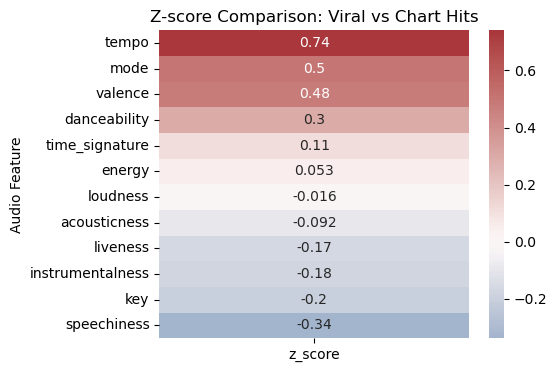

In [70]:
# making a heatmap plot to see the z-scores with more ease and which ones are at the extremes
fig1 = plt.figure(figsize=(5, 4))

sns.heatmap(
    compare[['z_score']].sort_values('z_score', ascending=False),
    annot=True,
    cmap='vlag', # found this palette on seaborn documentation
    center=0
)

plt.title('Z-score Comparison: Viral vs Chart Hits')
plt.ylabel('Audio Feature')
plt.show()

### 2. How has the chart's audio features changed throughout these 25 years?

##### Analysis:

In [71]:
# calling on the charts-audio table i merged in the analysis above
ca

,chart_week,list_position,track_id,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,2021-07-10,42,000TJlEJQ3nafsm1hBWpoj,0.620,0.586,1.0,-6.612,1.0,0.2120,0.155000,0.000000,0.5350,0.487,137.131,4.0
1,2003-07-19,60,003FTlCpBTM4eSqYSWPv4H,0.553,0.717,7.0,-5.857,1.0,0.0318,0.000065,0.128000,0.0385,0.318,127.947,4.0
2,2003-07-26,60,003FTlCpBTM4eSqYSWPv4H,0.553,0.717,7.0,-5.857,1.0,0.0318,0.000065,0.128000,0.0385,0.318,127.947,4.0
3,2003-08-02,64,003FTlCpBTM4eSqYSWPv4H,0.553,0.717,7.0,-5.857,1.0,0.0318,0.000065,0.128000,0.0385,0.318,127.947,4.0
4,2003-07-12,66,003FTlCpBTM4eSqYSWPv4H,0.553,0.717,7.0,-5.857,1.0,0.0318,0.000065,0.128000,0.0385,0.318,127.947,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129300,2004-04-17,74,7zywdG4ysfC5XNBzjQAo2o,0.443,0.885,7.0,-6.172,1.0,0.0414,0.123000,0.000031,0.2800,0.536,185.034,4.0
129301,2004-08-07,80,7zywdG4ysfC5XNBzjQAo2o,0.443,0.885,7.0,-6.172,1.0,0.0414,0.123000,0.000031,0.2800,0.536,185.034,4.0
129302,2004-08-14,81,7zywdG4ysfC5XNBzjQAo2o,0.443,0.885,7.0,-6.172,1.0,0.0414,0.123000,0.000031,0.2800,0.536,185.034,4.0
129303,2004-08-21,82,7zywdG4ysfC5XNBzjQAo2o,0.443,0.885,7.0,-6.172,1.0,0.0414,0.123000,0.000031,0.2800,0.536,185.034,4.0


In [72]:
# adding a 'chart_year' column to the ca table for ease of analysis
ca['chart_year'] = ca['chart_week'].dt.year

# rearranging the dataframe for ease
ca = ca[['chart_week', 'chart_year', 'list_position', 'track_id', 'danceability', 'energy', 'key',	'loudness',	'mode',	'speechiness',	'acousticness',	'instrumentalness',	'liveness',	'valence', 'tempo',	'time_signature']]
ca

,chart_week,chart_year,list_position,track_id,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,2021-07-10,2021,42,000TJlEJQ3nafsm1hBWpoj,0.620,0.586,1.0,-6.612,1.0,0.2120,0.155000,0.000000,0.5350,0.487,137.131,4.0
1,2003-07-19,2003,60,003FTlCpBTM4eSqYSWPv4H,0.553,0.717,7.0,-5.857,1.0,0.0318,0.000065,0.128000,0.0385,0.318,127.947,4.0
2,2003-07-26,2003,60,003FTlCpBTM4eSqYSWPv4H,0.553,0.717,7.0,-5.857,1.0,0.0318,0.000065,0.128000,0.0385,0.318,127.947,4.0
3,2003-08-02,2003,64,003FTlCpBTM4eSqYSWPv4H,0.553,0.717,7.0,-5.857,1.0,0.0318,0.000065,0.128000,0.0385,0.318,127.947,4.0
4,2003-07-12,2003,66,003FTlCpBTM4eSqYSWPv4H,0.553,0.717,7.0,-5.857,1.0,0.0318,0.000065,0.128000,0.0385,0.318,127.947,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129300,2004-04-17,2004,74,7zywdG4ysfC5XNBzjQAo2o,0.443,0.885,7.0,-6.172,1.0,0.0414,0.123000,0.000031,0.2800,0.536,185.034,4.0
129301,2004-08-07,2004,80,7zywdG4ysfC5XNBzjQAo2o,0.443,0.885,7.0,-6.172,1.0,0.0414,0.123000,0.000031,0.2800,0.536,185.034,4.0
129302,2004-08-14,2004,81,7zywdG4ysfC5XNBzjQAo2o,0.443,0.885,7.0,-6.172,1.0,0.0414,0.123000,0.000031,0.2800,0.536,185.034,4.0
129303,2004-08-21,2004,82,7zywdG4ysfC5XNBzjQAo2o,0.443,0.885,7.0,-6.172,1.0,0.0414,0.123000,0.000031,0.2800,0.536,185.034,4.0


In [73]:
# grouping by chart_year to find an average of every audio feauture for that year to plot them later
# calling on the 'audio_features' list i made before that contains all the column names for audio features
audio_trends = ca.groupby('chart_year')[audio_features].mean()
audio_trends

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
chart_year,,,,,,,,,,,,
2000,0.662418,0.688801,5.212642,-6.501304,0.620000,0.076566,0.150113,0.008136,0.153590,0.577940,117.285408,3.994717
2001,0.652913,0.682953,5.265947,-6.470427,0.652149,0.095370,0.155766,0.027780,0.177559,0.587633,115.524392,3.980921
2002,0.640161,0.692787,5.415912,-6.135291,0.636679,0.105083,0.161720,0.014408,0.157900,0.573446,118.399852,3.954729
2003,0.635861,0.691305,5.287418,-6.054089,0.637938,0.105557,0.169402,0.021004,0.178774,0.565988,115.582076,3.949788
2004,0.638167,0.696748,5.313654,-6.050579,0.656923,0.112682,0.165931,0.016464,0.180548,0.560875,119.817057,3.948846
2005,0.639683,0.682601,5.246792,-6.155417,0.676226,0.112197,0.149831,0.014199,0.177888,0.544243,120.843310,3.969434
2006,0.631926,0.705551,5.067323,-5.666268,0.676312,0.104521,0.133948,0.011680,0.185071,0.545206,122.375824,3.982060
2007,0.632562,0.714175,5.032544,-5.519029,0.706528,0.094773,0.139646,0.011196,0.182949,0.547105,123.476006,3.977085
2008,0.618074,0.708590,5.005392,-5.742978,0.735413,0.079625,0.139455,0.024801,0.180653,0.527614,125.010780,3.975737


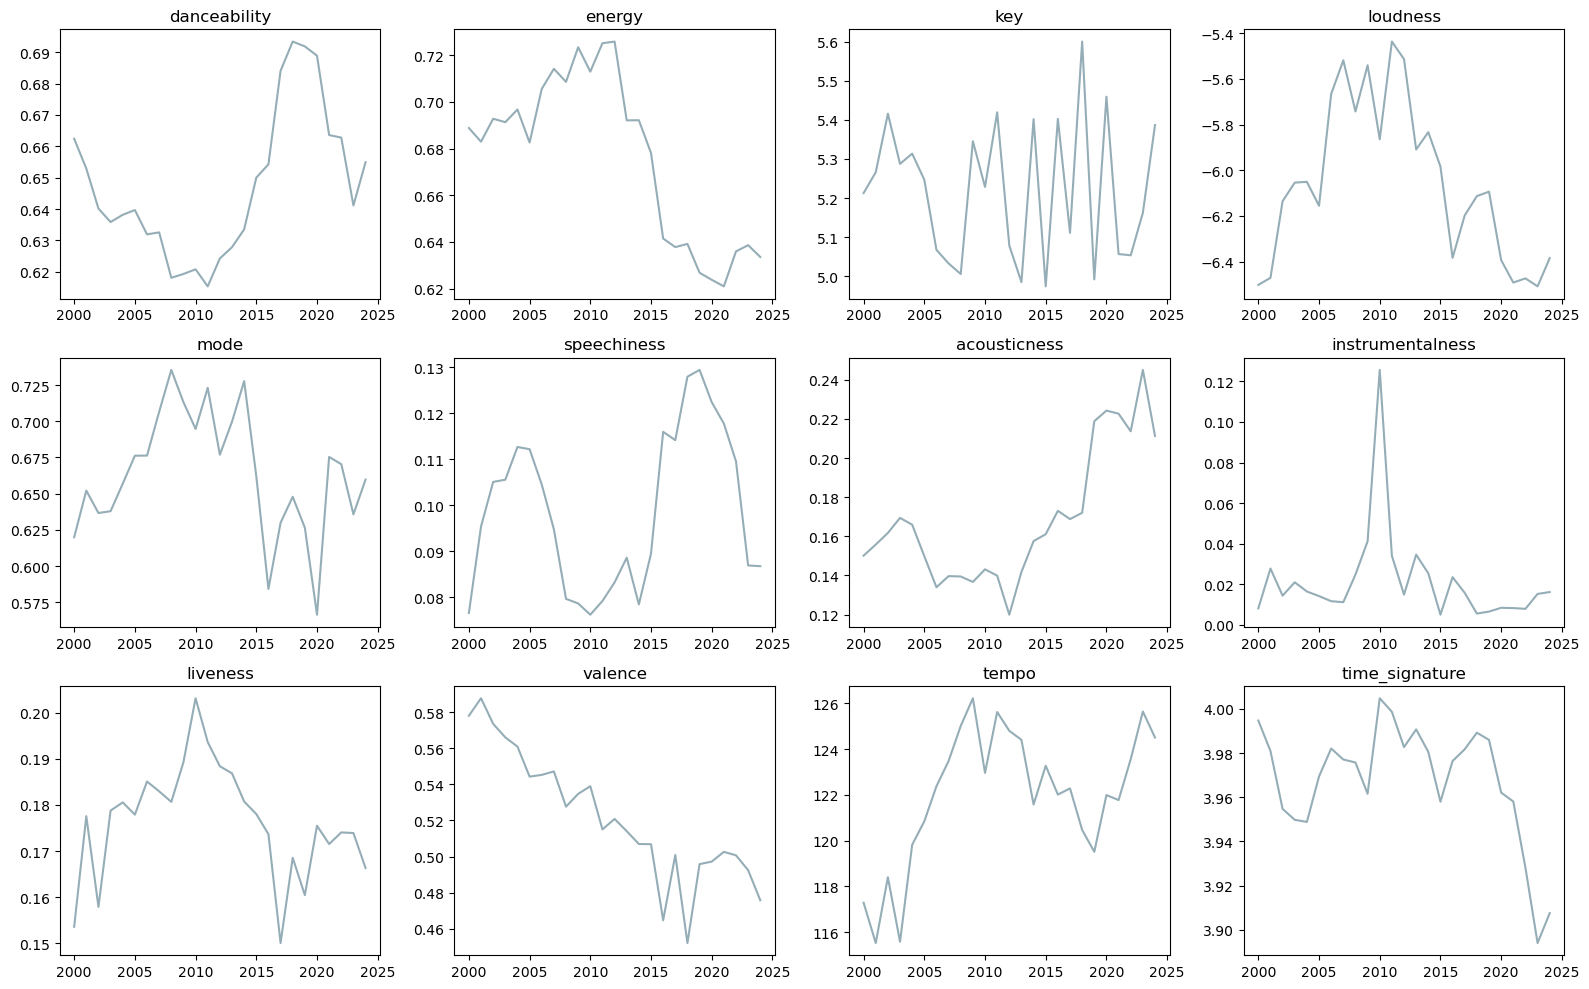

In [74]:
# plotting all this information at once and saving for easier callback
# setting an appropriate size for the small plots
fig2 = plt.figure(figsize=(16, 10))

# setting a counter so seaborn knows which plot it's plotting next in the loop
counter = 1
for feature in audio_trends:
    plt.subplot(3, 4, counter) # this counts the size of the plot and the counter puts it in the next position
    sns.lineplot(data=audio_trends, x='chart_year', y=feature, color='#95adb6')
    plt.title(feature, fontsize=12)
    plt.xlabel('') # not putting any labels to make it not so overwhelming to understand the plots
    plt.ylabel('')
    counter = counter + 1

# making the plot text etc. not overlap and showing it
plt.tight_layout()
plt.show()

### 3. What is the average duration of the chart's songs throughout these 25 years?

##### Analysis:

In [75]:
# exploring the tracks table
tracks

,track_id,name,duration_ms,release_date,album_type,explicit
0,5CMVGP24paZIukljDj0iWc,Jingle Bells (with The Ken Lane Singers),156666,1945-01-01,compilation,False
1,04vLj9QUXoKdRlsp3gkURo,Mele Kalikimaka (Merry Christmas),175333,1945-01-01,compilation,False
2,25leEEaz1gIpp7o21Fqyjo,Here Comes Santa Claus (Right Down Santa Claus...,150266,1947-01-01,album,False
3,1dtIaSlyrLI04sqYa8nLyN,Rudolph the Red-Nosed Reindeer,186733,1947-01-01,album,False
4,4HEOgBHRCExyYVeTyrXsnL,Jingle Bells - Remastered 1999,120693,1957-09-01,album,False
...,...,...,...,...,...,...
10776,5sRczgK1xkskY6HICpEKHa,"yes, and? - live version",199448,2024-10-01,album,True
10777,21SiVKUZKwWmL5C64G3R3e,don't wanna break up again,174006,2024-10-01,album,True
10778,4nQLt9m4p0fLUMOogvV6ZN,imperfect for you - live version,186201,2024-10-01,album,True
10779,4M7DbskLseolYL7rooP1SN,My Story,227813,2024-10-04,album,True


In [76]:
# merging the ca table (charts and audio tables) with tracks to see duration and explicitness
# merging from the left to keep all info in ca table and only the info that matches from the tracks table

cat = ca.merge(tracks, on='track_id', how='left')

# rearranging the table's columns for structure
cat = cat[['chart_week', 'chart_year', 'list_position', 'track_id', 'name', 'duration_ms', 'release_date','album_type', 'explicit', 'danceability',
       'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']]
cat

,chart_week,chart_year,list_position,track_id,name,duration_ms,release_date,album_type,explicit,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,2021-07-10,2021,42,000TJlEJQ3nafsm1hBWpoj,LEMONHEAD (feat. 42 Dugg),130979,2023-03-31,album,True,0.620,...,1.0,-6.612,1.0,0.2120,0.155000,0.000000,0.5350,0.487,137.131,4.0
1,2003-07-19,2003,60,003FTlCpBTM4eSqYSWPv4H,"Swing, Swing",233266,2002-10-15,album,False,0.553,...,7.0,-5.857,1.0,0.0318,0.000065,0.128000,0.0385,0.318,127.947,4.0
2,2003-07-26,2003,60,003FTlCpBTM4eSqYSWPv4H,"Swing, Swing",233266,2002-10-15,album,False,0.553,...,7.0,-5.857,1.0,0.0318,0.000065,0.128000,0.0385,0.318,127.947,4.0
3,2003-08-02,2003,64,003FTlCpBTM4eSqYSWPv4H,"Swing, Swing",233266,2002-10-15,album,False,0.553,...,7.0,-5.857,1.0,0.0318,0.000065,0.128000,0.0385,0.318,127.947,4.0
4,2003-07-12,2003,66,003FTlCpBTM4eSqYSWPv4H,"Swing, Swing",233266,2002-10-15,album,False,0.553,...,7.0,-5.857,1.0,0.0318,0.000065,0.128000,0.0385,0.318,127.947,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129300,2004-04-17,2004,74,7zywdG4ysfC5XNBzjQAo2o,If You Ever Stop Loving Me,202760,2004-05-18,album,False,0.443,...,7.0,-6.172,1.0,0.0414,0.123000,0.000031,0.2800,0.536,185.034,4.0
129301,2004-08-07,2004,80,7zywdG4ysfC5XNBzjQAo2o,If You Ever Stop Loving Me,202760,2004-05-18,album,False,0.443,...,7.0,-6.172,1.0,0.0414,0.123000,0.000031,0.2800,0.536,185.034,4.0
129302,2004-08-14,2004,81,7zywdG4ysfC5XNBzjQAo2o,If You Ever Stop Loving Me,202760,2004-05-18,album,False,0.443,...,7.0,-6.172,1.0,0.0414,0.123000,0.000031,0.2800,0.536,185.034,4.0
129303,2004-08-21,2004,82,7zywdG4ysfC5XNBzjQAo2o,If You Ever Stop Loving Me,202760,2004-05-18,album,False,0.443,...,7.0,-6.172,1.0,0.0414,0.123000,0.000031,0.2800,0.536,185.034,4.0


In [77]:
# making a table to use for the lineplot to show the average duration of a track per release_year
cat_avg_duration = cat.groupby('chart_year')['duration_ms'].mean().to_frame('avg_duration_ms')
cat_avg_duration

,avg_duration_ms
chart_year,
2000,249176.076602
2001,242759.028136
2002,242199.49451
2003,244012.501731
2004,239239.904423
2005,235311.210377
2006,233050.206154
2007,237354.677885
2008,234985.212885


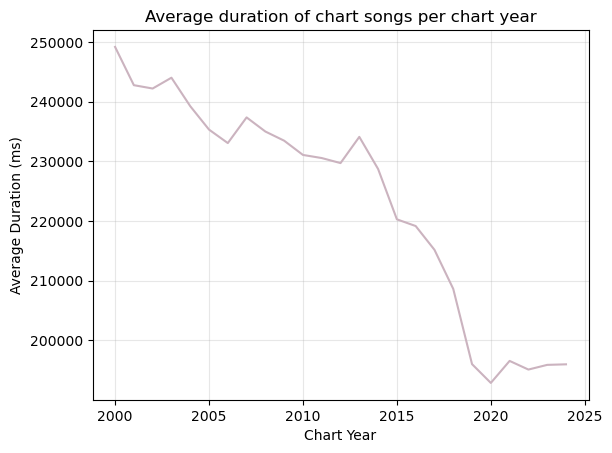

In [78]:
# using the table above in a lineplot and saving it for easier calling
fig3 = plt.figure()
sns.lineplot(data=cat_avg_duration, x='chart_year', y='avg_duration_ms', color='#CBB3BF'),
plt.title('Average duration of chart songs per chart year'),
plt.ylabel('Average Duration (ms)'),
plt.xlabel('Chart Year')
plt.grid(visible=True, alpha=0.3)
plt.show()

### 4. What about explicit and non-explicit songs in the charts?

##### Analysis:

In [79]:
# starting to find the share of explicit songs over these 25 years
tracks

,track_id,name,duration_ms,release_date,album_type,explicit
0,5CMVGP24paZIukljDj0iWc,Jingle Bells (with The Ken Lane Singers),156666,1945-01-01,compilation,False
1,04vLj9QUXoKdRlsp3gkURo,Mele Kalikimaka (Merry Christmas),175333,1945-01-01,compilation,False
2,25leEEaz1gIpp7o21Fqyjo,Here Comes Santa Claus (Right Down Santa Claus...,150266,1947-01-01,album,False
3,1dtIaSlyrLI04sqYa8nLyN,Rudolph the Red-Nosed Reindeer,186733,1947-01-01,album,False
4,4HEOgBHRCExyYVeTyrXsnL,Jingle Bells - Remastered 1999,120693,1957-09-01,album,False
...,...,...,...,...,...,...
10776,5sRczgK1xkskY6HICpEKHa,"yes, and? - live version",199448,2024-10-01,album,True
10777,21SiVKUZKwWmL5C64G3R3e,don't wanna break up again,174006,2024-10-01,album,True
10778,4nQLt9m4p0fLUMOogvV6ZN,imperfect for you - live version,186201,2024-10-01,album,True
10779,4M7DbskLseolYL7rooP1SN,My Story,227813,2024-10-04,album,True


In [80]:
charts

,chart_week,list_position,track_id
0,2021-07-10,42,000TJlEJQ3nafsm1hBWpoj
1,2003-07-19,60,003FTlCpBTM4eSqYSWPv4H
2,2003-07-26,60,003FTlCpBTM4eSqYSWPv4H
3,2003-08-02,64,003FTlCpBTM4eSqYSWPv4H
4,2003-07-12,66,003FTlCpBTM4eSqYSWPv4H
...,...,...,...
129300,2004-04-17,74,7zywdG4ysfC5XNBzjQAo2o
129301,2004-08-07,80,7zywdG4ysfC5XNBzjQAo2o
129302,2004-08-14,81,7zywdG4ysfC5XNBzjQAo2o
129303,2004-08-21,82,7zywdG4ysfC5XNBzjQAo2o


In [81]:
# adding a 'year' column to the charts df for ease of analysis
charts['chart_year'] = charts['chart_week'].dt.year

# rearranging the dataframe for ease
charts = charts[['chart_week', 'chart_year', 'list_position', 'track_id']]
charts

,chart_week,chart_year,list_position,track_id
0,2021-07-10,2021,42,000TJlEJQ3nafsm1hBWpoj
1,2003-07-19,2003,60,003FTlCpBTM4eSqYSWPv4H
2,2003-07-26,2003,60,003FTlCpBTM4eSqYSWPv4H
3,2003-08-02,2003,64,003FTlCpBTM4eSqYSWPv4H
4,2003-07-12,2003,66,003FTlCpBTM4eSqYSWPv4H
...,...,...,...,...
129300,2004-04-17,2004,74,7zywdG4ysfC5XNBzjQAo2o
129301,2004-08-07,2004,80,7zywdG4ysfC5XNBzjQAo2o
129302,2004-08-14,2004,81,7zywdG4ysfC5XNBzjQAo2o
129303,2004-08-21,2004,82,7zywdG4ysfC5XNBzjQAo2o


In [82]:
# merging the charts dataframe to the tracks one and keeping only the necessary info
# merging from the left to keep all information on charts and the info that matches from tracks
tc = charts.merge(tracks[['track_id','name','explicit']], on='track_id', how='left')
tc

,chart_week,chart_year,list_position,track_id,name,explicit
0,2021-07-10,2021,42,000TJlEJQ3nafsm1hBWpoj,LEMONHEAD (feat. 42 Dugg),True
1,2003-07-19,2003,60,003FTlCpBTM4eSqYSWPv4H,"Swing, Swing",False
2,2003-07-26,2003,60,003FTlCpBTM4eSqYSWPv4H,"Swing, Swing",False
3,2003-08-02,2003,64,003FTlCpBTM4eSqYSWPv4H,"Swing, Swing",False
4,2003-07-12,2003,66,003FTlCpBTM4eSqYSWPv4H,"Swing, Swing",False
...,...,...,...,...,...,...
129300,2004-04-17,2004,74,7zywdG4ysfC5XNBzjQAo2o,If You Ever Stop Loving Me,False
129301,2004-08-07,2004,80,7zywdG4ysfC5XNBzjQAo2o,If You Ever Stop Loving Me,False
129302,2004-08-14,2004,81,7zywdG4ysfC5XNBzjQAo2o,If You Ever Stop Loving Me,False
129303,2004-08-21,2004,82,7zywdG4ysfC5XNBzjQAo2o,If You Ever Stop Loving Me,False


In [83]:
# since explicit is a boolean (1, 0) we can calculate mean to find the average explicit score for each year
explicit_trend = round(tc.groupby('chart_year')['explicit'].mean().to_frame('explicit_share'), 3)

# adding a percentage for clarity
explicit_trend['explicit_%'] = explicit_trend['explicit_share'] * 100
explicit_trend

,explicit_share,explicit_%
chart_year,,
2000,0.153,15.3
2001,0.207,20.7
2002,0.23,23.0
2003,0.215,21.5
2004,0.256,25.6
2005,0.25,25.0
2006,0.218,21.8
2007,0.211,21.1
2008,0.154,15.4


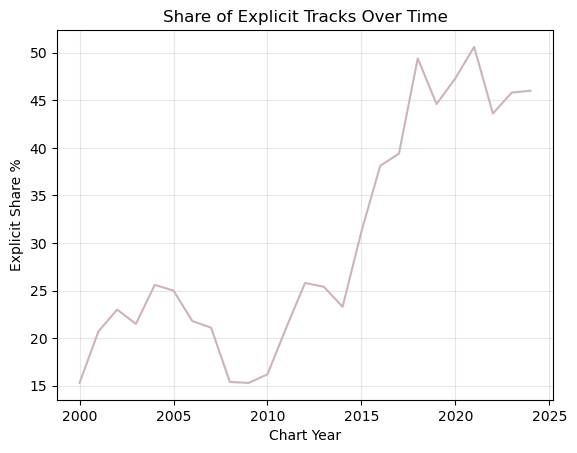

In [84]:
# plotting this trend to see how it has evolved the past 25 years and saving it for ease
fig4 = plt.figure()
sns.lineplot(data=explicit_trend, x='chart_year', y='explicit_%', color='#CBB3BF')
plt.title('Share of Explicit Tracks Over Time')
plt.xlabel('Chart Year')
plt.ylabel('Explicit Share %')
plt.grid(visible=True, alpha=0.3)
plt.show()

In [85]:
# now beginning to find if explicit songs perform better than non-explicit songs through time
tc

,chart_week,chart_year,list_position,track_id,name,explicit
0,2021-07-10,2021,42,000TJlEJQ3nafsm1hBWpoj,LEMONHEAD (feat. 42 Dugg),True
1,2003-07-19,2003,60,003FTlCpBTM4eSqYSWPv4H,"Swing, Swing",False
2,2003-07-26,2003,60,003FTlCpBTM4eSqYSWPv4H,"Swing, Swing",False
3,2003-08-02,2003,64,003FTlCpBTM4eSqYSWPv4H,"Swing, Swing",False
4,2003-07-12,2003,66,003FTlCpBTM4eSqYSWPv4H,"Swing, Swing",False
...,...,...,...,...,...,...
129300,2004-04-17,2004,74,7zywdG4ysfC5XNBzjQAo2o,If You Ever Stop Loving Me,False
129301,2004-08-07,2004,80,7zywdG4ysfC5XNBzjQAo2o,If You Ever Stop Loving Me,False
129302,2004-08-14,2004,81,7zywdG4ysfC5XNBzjQAo2o,If You Ever Stop Loving Me,False
129303,2004-08-21,2004,82,7zywdG4ysfC5XNBzjQAo2o,If You Ever Stop Loving Me,False


In [86]:
# calculating the average list position for explicit vs non-explicit tracks
avg_pos_exp = tc.groupby('explicit')['list_position'].mean().round().astype(int).to_frame()
avg_pos_exp

,list_position
explicit,
False,50
True,51


Text(0, 0.5, 'List Position')

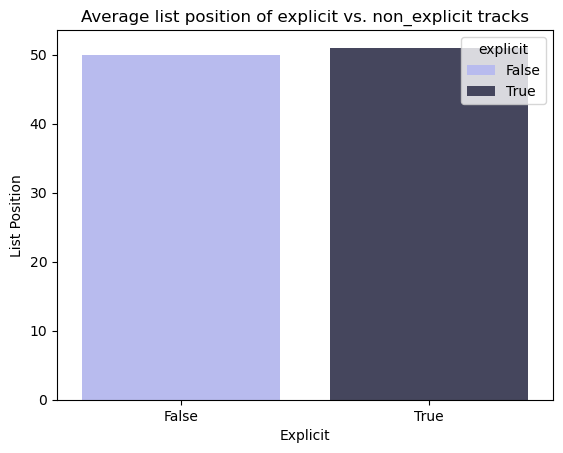

In [87]:
# plotting a bar plot to see the difference
# need to add hue as only using palette without hue will be deprecated in newer versions of sns
sns.barplot(data=avg_pos_exp, x='explicit', y='list_position', hue='explicit', palette=['#afb3f7', '#414361'])
plt.title('Average list position of explicit vs. non_explicit tracks')
plt.xlabel('Explicit')
plt.ylabel('List Position')

Doesn't really have a difference as they are charting at 51 for explicit songs and 50 for non-explicit ones.

What about throughout the years?

In [88]:
# calculating the average list position for explicit vs non-explicit tracks throughout the years
# setting the max columns to true so we can see all columns

pd.set_option('display.max_columns', None)

avg_ypos_exp = (tc.pivot_table(
    index='explicit', 
    columns='chart_year', 
    values='list_position', 
    aggfunc='mean').round().astype(int)
               )
avg_ypos_exp

chart_year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
explicit,,,,,,,,,,,,,,,,,,,,,,,,,
False,49,49,51,52,52,52,53,52,50,50,51,51,50,49,49,50,49,50,53,51,49,53,50,48,49
True,60,55,50,45,46,46,43,44,51,53,49,50,53,54,55,52,53,52,48,50,52,48,51,53,52


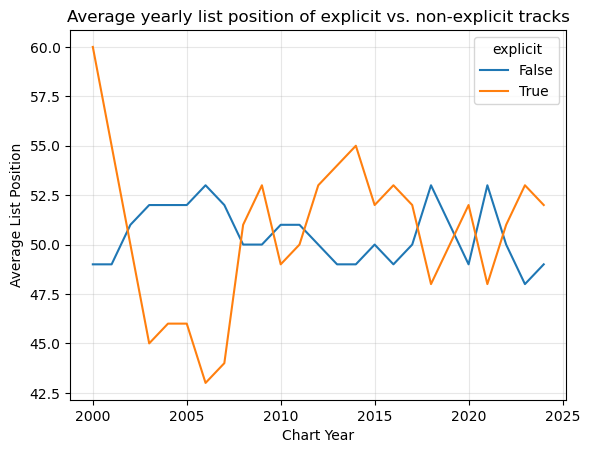

In [89]:
# plotting a lineplot and saving it
# have to melt the table first
plot_df = (
    avg_ypos_exp
    .reset_index()
    .melt(id_vars='explicit', var_name='chart_year', value_name='list_position')
)

fig5 = plt.figure()
sns.lineplot(
    data=plot_df,
    x='chart_year',
    y='list_position',
    hue='explicit'
)
plt.title('Average yearly list position of explicit vs. non-explicit tracks') 
plt.xlabel('Chart Year') 
plt.ylabel('Average List Position')
plt.grid(visible=True, alpha=0.3)
plt.show()

In [113]:
# making a table with their differences
new = avg_ypos_exp.T
new['diff'] = new[False] - new[True]
new = new.reset_index()
new["chart_year"] = new["chart_year"].astype(str)
new = new.sort_values("diff")
new

explicit,chart_year,False,True,diff
0,2000,49,60,-11
1,2001,49,55,-6
14,2014,49,55,-6
13,2013,49,54,-5
23,2023,48,53,-5
16,2016,49,53,-4
20,2020,49,52,-3
9,2009,50,53,-3
12,2012,50,53,-3
24,2024,49,52,-3


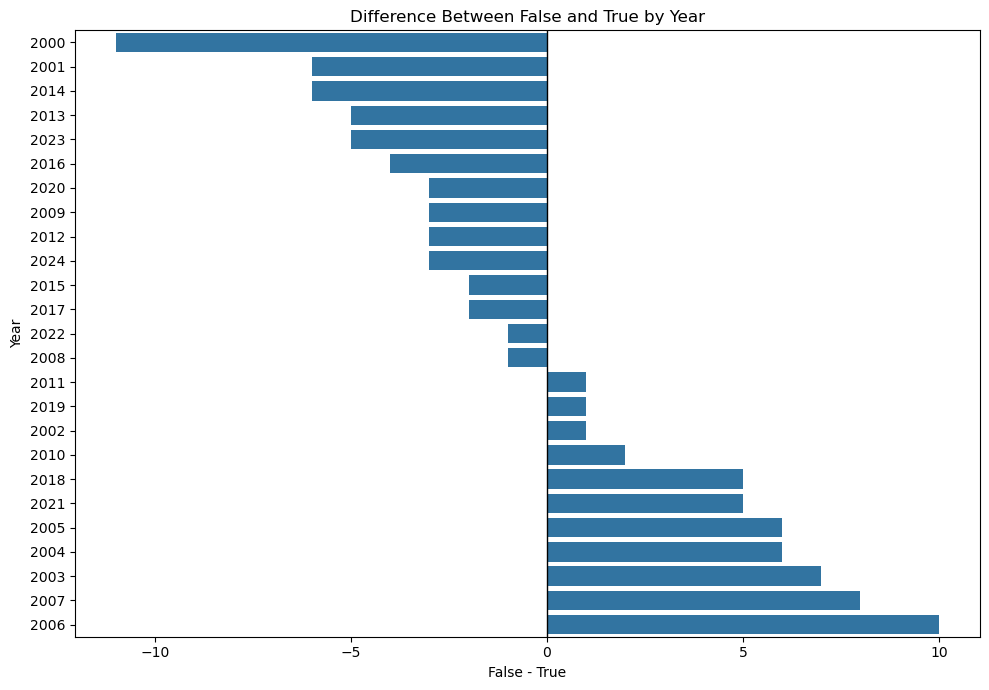

In [114]:
# plotting this as a barchart
plt.figure(figsize=(10, 7)) 
sns.barplot( data=new, y="chart_year", x="diff") 
plt.axvline(0, color="black", linewidth=1) 
plt.title("Difference Between False and True by Year") 
plt.xlabel("False - True") 
plt.ylabel("Year") 
plt.tight_layout() 
plt.show()

# Presentation

## The Big Question: How Have Chart Hits Changed Over the Past 25 Years?

*By Dimitra Pieta — for Rolling Beats Magazine*

### Hit songs have transformed over the past 25 years, developing a distinct viral sound, shifting toward calmer and more rhythm‑focused styles overall, becoming shorter in structure, and embracing more explicit lyrical norms, all in parallel with the rise of the music streaming era and maybe TikTok?

#### 1. The most viral songs of all-time sound happier, are faster and more danceable than other hits.

The data and figure 1 (fig1) shows that:
- The most viral songs stand out in **tempo** (z = 0.74) and **valence** (z = 0.48), meaning they are more positive in lyrics and faster than the average track. 
- They lean strongly toward major **mode** (z = 0.50), reinforcing that happier sound.
- **Danceability** is moderately elevated (z = 0.30), while **energy** is only slightly above average (z = 0.05), suggesting the hits rely more on rhythmic feel and positivity than just intensity.
- On the other side, viral songs show notably lower **speechiness** (z = –0.34), along with small negative deviations in **acousticness**, **instrumentalness**, and **liveness**, indicating a preference for vocal‑driven studio production rather than rap-heavy, instrumental, or live‑sounding styles.

Overall, the data reveals a consistent pattern: 

The most viral hits cluster around a **fast, happy, major‑key pop profile with clean production and danceable rhythms**.

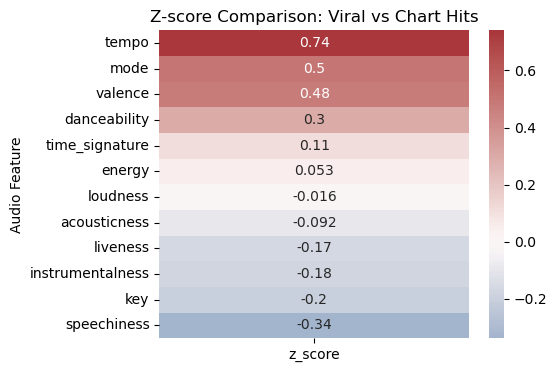

In [150]:
fig1

#### 2. When it comes to the audio features of the charts the past 25 years, there is a shift from loud, high‑energy, fast profile of the 2000's toward calmer, more acoustic, less positive, and more rhythm‑focused styles today.

The data and figure 2 (fig2) shows that:

- `Danceability` follows a U‑shaped pattern, declining through the 2000s, hitting a clear low around 2009–2011, then rising sharply to its highest point in 2017–2019 before falling again in the early 2020s.

- `Energy` rises through the 2000s, peaking around 2011–2012, then dropping sharply between 2013 and 2016 and remaining consistently lower through 2024.

- `Loudness` mirrors the energy arc, increasing steadily until 2010–2012 and then declining almost continuously to its lowest levels in the early 2020s.

- `Valence` shows a clear long‑term decline, starting relatively high around 2000 and falling steadily across the entire period, ending at its lowest point after 2020.

- `Acousticness` remains low through the 2000s, dips slightly around 2011–2012, then rises consistently from 2014 onward, peaking in the early 2020s.

- `Speechiness` fluctuates sharply, dropping to its lowest point around 2009–2011, then rising steeply to a peak in 2018–2019 before declining again after 2020.

- `Instrumentalness` stays near zero except for a brief, isolated spike around 2010 that is not sustained.

- `Tempo` increases into the late 2000s, peaking around 2009–2011, then drifting downward through the mid‑to‑late 2010s before rising again after 2020.

- `Mode` and `Liveness` show volatility rather than direction, with mode peaking in the late 2000s and dipping in the mid‑2010s, and liveness peaking around 2009–2010 before gradually declining.

- `Key` varies year to year without a consistent trend, and time signature remains tightly centered on 4 with only a slight downward drift in recent years.

Overall:

Chart music has shifted from the loud, high‑energy, fast profile of the late 2000s **toward calmer, more acoustic, less positive, and more rhythm‑focused styles in the 2010s and 2020s**, with danceability and speech‑driven elements rising even as energy, loudness, and valence decline.

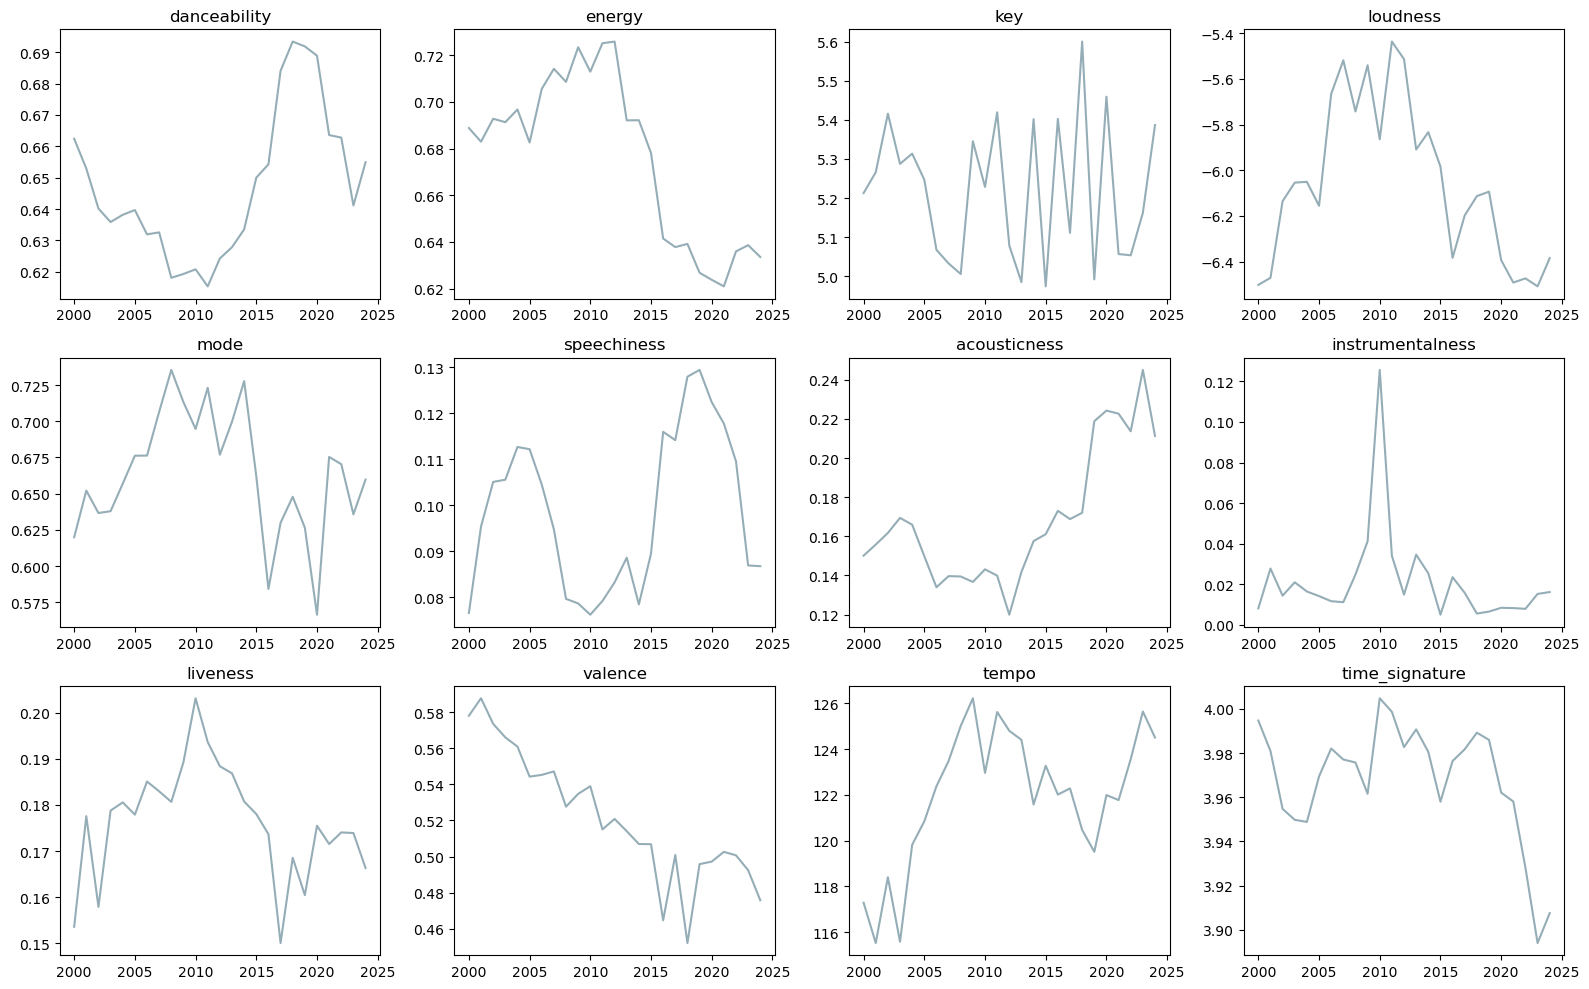

In [151]:
fig2

#### 3. The song duration on the Hot 100s has steadily decreased over time. Maybe TikTok has something to do with it?

Across 25 years of chart data, one pattern stands out clearly:

- The songs that enter the Hot 100 have been getting steadily shorter. From 4 minutes and 15 seconds in the year 2000 to 3 minutes and 27 seconds in the year 2024 to be exact!

When we look at the average duration of every track that appeared on the charts each year (fig3), the trend forms a smooth downward slope, especially after the mid‑2010s, when streaming became the dominant listening format. The shift accelerates even further in the late 2010s and early 2020s with the rise of short‑form video platforms like TikTok, where songs often go viral through 10–20‑second clips rather than full‑length listening.

In this environment, listeners are increasingly engaging with music in quick, fragmented bursts. It’s possible that this shift has contributed to a broader shortening of effective attention spans around music, making fast‑moving, tightly structured tracks more competitive. Shorter attention spans may be one of several forces nudging creators towards creating shorter tracks, reinforcing the long‑term decline in average song duration on the charts.

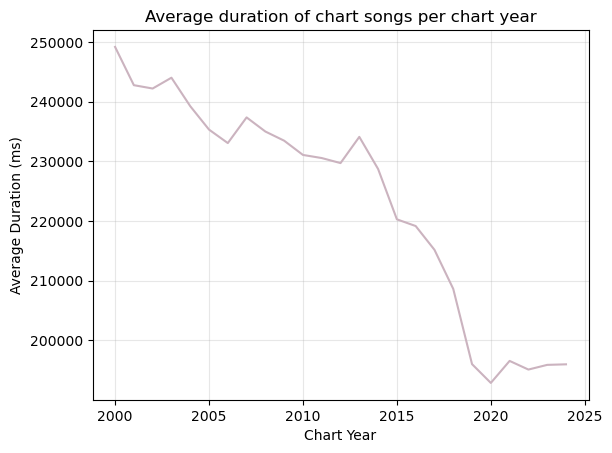

In [152]:
fig3

#### 4. Explicit tracks have exploded to 50% of all chart's songs after the streaming era but they don't necessarily perform better than non-explicit tracks.

According to the data and figure 4 (fig4):
- The share of the explicit tracks for the years after 2015 are almost 50% (0.46) of the entire charts list for these years. Half the songs are marked as explicit! That is a stark difference from the years before and especially the 2000's when the share was 0.15 or 15%!

In addition, the share of explicit tracks was much lower in the pre‑streaming era, when radio and physical sales still shaped what became popular. This could be because those formats favored clean versions, so explicit songs appeared less often on the charts. As streaming took over around 2015, that barrier seems to have faded. Listeners could quickly choose to listen to whatever they wanted, and platforms didn’t filter out explicit content. 

The chart shows this shift clearly: explicit tracks grow slowly in the early 2000s, then rise sharply as streaming becomes the main way people discover music (fig5).

Performance-wise, explicit songs started out doing worse in the early 2000s, but they improved really quickly:
- There’s a sharp jump where their average chart position gets much better. After that, the gap between explicit and non‑explicit tracks basically disappears. From around 2010 onward, the two lines move almost the same way, sometimes one doing slightly better, sometimes the other.

Overall, it shows that explicit songs used to be at a disadvantage, but that changed fast, and today explicit or not doesn’t really affect how well a song performs on the charts.

The better performance of explicit songs during 2010-2020 could also go hand in hand in with the surge in explicit track share we saw during that time above.

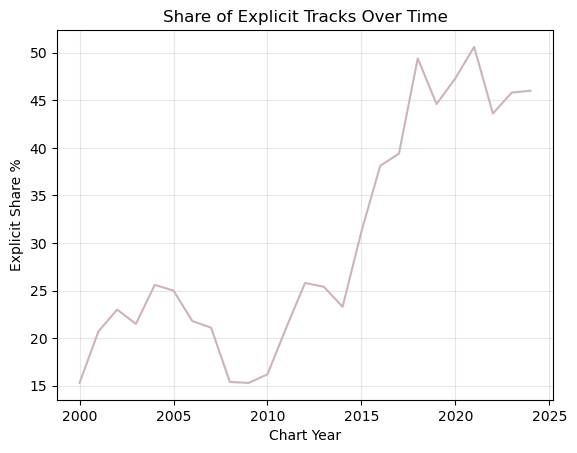

In [153]:
fig4

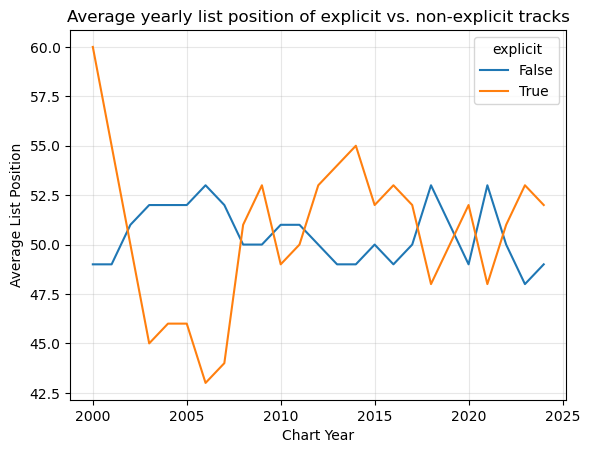

In [154]:
fig5